In [2]:
import pandas as pd 
import seaborn as sns

In [3]:
housingData = pd.read_csv("Housing.csv")
housingData

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


<Axes: xlabel='area', ylabel='price'>

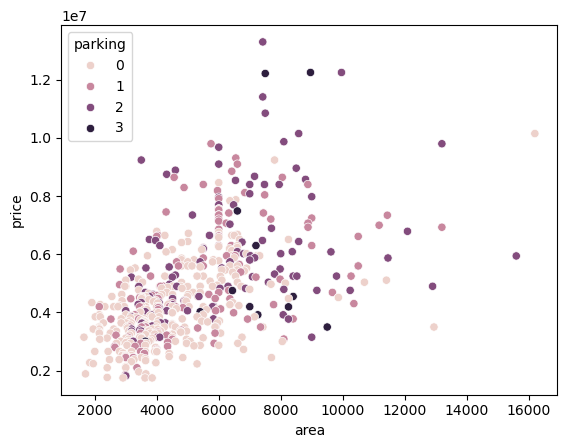

In [8]:
sns.scatterplot(x= housingData["area"], y= housingData["price"], hue = housingData["parking"])

In [9]:
housingData.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [22]:
X = housingData[["area", "bedrooms", "stories", "mainroad"]].copy()
Y = housingData["price"]

X["mainroad"] = X["mainroad"].map({"yes": 1, "no":0 })
#Train-Test split:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

In [23]:
# Train Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
#predict values
y_predict = model.predict(X_test)

In [25]:
y_predict

array([4951391.87459648, 6002199.40800903, 3537892.17529096,
       4895988.37729733, 3952661.28393396, 4929964.90802395,
       5567336.83677828, 5335544.17205855, 2548236.54551226,
       2800121.71680693, 7756882.58790698, 3500358.05059764,
       2718202.39318008, 3516827.67994653, 4531269.99584346,
       3704498.30341309, 3390605.07945246, 5250083.89327196,
       5196969.56587576, 4231919.38660124, 6053205.80111632,
       4967144.93720128, 3399440.82854487, 4471073.75812777,
       5471731.04746513, 6652302.13653151, 3201501.43511505,
       4187797.34534806, 7799571.60828932, 3744700.59542709,
       4541892.86132269, 4230288.80726502, 5825151.65002171,
       5467852.63559636, 5259413.63612401, 4754350.17090747,
       4770638.56464231, 4694631.28814447, 3076316.21926715,
       4555471.75036644, 5376125.25815198, 3392713.01374136,
       5973871.76673106, 4612711.96451762, 4497491.02358221,
       4191198.40226415, 6400219.40677146, 5211610.74146743,
       4957815.19434923,

In [26]:
# Evaluate 
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_predict)
print("r-squared:", r2)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2) * (n-1) / (n-p-1))
print("adjusted r^2:", adjusted_r2)

r-squared: 0.46196564510110816
adjusted r^2: 0.44127201606653543
